# The Koran

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly_express as px
import plotly.io as pio
pio.renderers.default = 'jupyterlab'
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF, PCA, LatentDirichletAllocation as LDA
from sklearn.cluster import KMeans

import sys; sys.path.append("../../local_lib/")

from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

from glob import glob

ModuleNotFoundError: No module named 'plotly_express'

# Text

Source https://blog.clearquran.com/download

In [ ]:
base_dir = "./quran-verse-by-verse-text"
src_file_names = glob(f"{base_dir}/*.txt")
data = []
for file_name in sorted(src_file_names):
    chap_num, verse_num = file_name.strip().split("/")[2].split('.')[0].split("-")
    line_str = open(file_name, "r").read()
    data.append((int(chap_num), int(verse_num), line_str))

In [ ]:
data[0]

(1, 1, 'In the name of God, the Gracious, the Merciful.')

# DOC

In [ ]:
DOC = pd.DataFrame(data, columns=['chap_num','verse_num','line_str']).set_index(['chap_num', 'verse_num'])

In [ ]:
DOC

line_str
chap_num verse_num                                                   
1        1            In the name of God, the Gracious, the Merciful.
         2                      Praise be to God, Lord of the Worlds.
         3                      The Most Gracious, the Most Merciful.
         4                             Master of the Day of Judgment.
         5          It is You we worship, and upon You we call for...
...                                                               ...
114      2                                       The King of mankind.
         3                                        The God of mankind.
         4                     From the evil of the sneaky whisperer.
         5                    Who whispers into the hearts of people.
         6                         From among jinn and among people.”

[6348 rows x 1 columns]

# CHAP

In [ ]:
CHAP = DOC.groupby(['chap_num']).line_str.apply(lambda x: ' '.join(map(str, x))).to_frame('chap_str')

In [ ]:
CHAP['n_tokens'] = CHAP.chap_str.str.split().str.len()

In [ ]:
CHAP

,chap_str,n_tokens
chap_num,,
1,"In the name of God, the Gracious, the Merciful...",68
2,"In the name of God, the Gracious, the Merciful...",10764
3,"In the name of God, the Gracious, the Merciful...",6151
4,"In the name of God, the Gracious, the Merciful...",6343
5,"In the name of God, the Gracious, the Merciful...",4975
...,...,...
110,"In the name of God, the Gracious, the Merciful...",43
111,"In the name of God, the Gracious, the Merciful...",51
112,"In the name of God, the Gracious, the Merciful...",32


In [ ]:
CHAP.chap_str = CHAP.chap_str.replace(r"In the name of God, the Gracious, the Merciful.", "", regex=True)

In [ ]:
# CHAP

# TOKEN

In [ ]:
TOKEN = DOC.line_str.str.split(expand=True).stack().to_frame('token_str')

In [ ]:
TOKEN.index.names = list(DOC.index.names[:2]) + ['token_num']

In [ ]:
TOKEN['term_str'] = TOKEN.token_str.str.lower().str.replace(r"\W", "", regex=True)

In [ ]:
TOKEN

token_str term_str
chap_num verse_num token_num                   
1        1         0                In       in
                   1               the      the
                   2              name     name
                   3                of       of
                   4              God,      god
...                                ...      ...
114      6         1             among    among
                   2              jinn     jinn
                   3               and      and
                   4             among    among
                   5          people.”   people

[140044 rows x 2 columns]

# CHUNK

In [ ]:
n_chunks = 100
TOKEN['chunk_id'] = (
    pd.DataFrame(np.array_split(TOKEN.index, n_chunks))
    .stack()
    .reset_index()
    .level_0
    .values + 1
)

In [ ]:
TOKEN

token_str term_str  chunk_id
chap_num verse_num token_num                             
1        1         0                In       in         1
                   1               the      the         1
                   2              name     name         1
                   3                of       of         1
                   4              God,      god         1
...                                ...      ...       ...
114      6         1             among    among       100
                   2              jinn     jinn       100
                   3               and      and       100
                   4             among    among       100
                   5          people.”   people       100

[140044 rows x 3 columns]

In [ ]:
CHUNK = TOKEN.value_counts('chunk_id').sort_index().to_frame('n_tokens')

In [ ]:
CHUNK

,n_tokens
chunk_id,
1,1401
2,1401
3,1401
4,1401
5,1401
...,...
96,1400
97,1400
98,1400


# BOW / CTM

In [ ]:
CTM = TOKEN.value_counts(['chunk_id', 'term_str']).unstack(fill_value=0)

In [ ]:
CTM

term_str,a,aad,aaron,abandon,abandoned,abase,abated,abates,abee,abide,...,youthen,youthese,youths,youwhich,youyou,zaid,zanjabeel,zechariah,zoroastrians,zulqarnain
chunk_id,,,,,,,,,,,,,,,,,,,,,
1,18,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,28,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,41,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
98,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# VOCAB

In [ ]:
VOCAB = CTM.sum().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['grams'] = VOCAB.apply(lambda x: len(x.name.split()), axis=1)

from stopwords import ENGLISH_STOP_WORDS as swlist

SW = pd.Series(1, index=swlist)
SW.index.name = 'term_str'
SW.name = 'sw'

VOCAB = VOCAB.join(SW)
VOCAB.sw = VOCAB.sw.fillna(0).astype(bool)

In [ ]:
VOCAB['df'] = CTM.astype(bool).sum()
VOCAB['dp'] = VOCAB.df / n_chunks
VOCAB['dh'] = VOCAB.dp * np.log2(1/VOCAB.dp)

In [ ]:
VOCAB

,n,grams,sw,df,dp,dh
term_str,,,,,,
a,1967,1,True,100,1.00,0.000000
aad,24,1,False,17,0.17,0.434587
aaron,20,1,False,14,0.14,0.397110
abandon,9,1,False,9,0.09,0.312654
abandoned,4,1,False,4,0.04,0.185754
...,...,...,...,...,...,...
zaid,1,1,False,1,0.01,0.066439
zanjabeel,1,1,False,1,0.01,0.066439
zechariah,7,1,False,4,0.04,0.185754


In [ ]:
px.scatter(VOCAB.reset_index(), 'n', 'dh', 
           log_x=True, 
           width=750, height=500,
           hover_name='term_str',
           marginal_y='histogram',
           color='sw',
          title="Term Significance (<i>dh</i>) v Frequency (<i>n</i>)")

In [ ]:
px.scatter(VOCAB.reset_index(), 'df', 'dh', 
           log_x=False, 
           width=750, height=500,
           hover_name='term_str',
           marginal_y='histogram',
          title="Term Significance (<i>dh</i>) v Doc Frequency (<i>df</i>)")

In [ ]:
max_entropy = VOCAB.dh.agg('median')

In [ ]:
VOCAB['sig'] = (VOCAB.dh >= max_entropy) & (VOCAB.sw == False)

In [ ]:
VOCAB[VOCAB.sig == True].sample(10, weights='dh')

,n,grams,sw,df,dp,dh,sig
term_str,,,,,,,
attainment,2,1,False,2,0.02,0.112877,True
ridiculed,12,1,False,10,0.10,0.332193,True
utterly,6,1,False,6,0.06,0.243534,True
godhe,6,1,False,3,0.03,0.151767,True
hard,4,1,False,4,0.04,0.185754,True
spirit,20,1,False,19,0.19,0.455226,True
scriptures,7,1,False,6,0.06,0.243534,True
israel,43,1,False,26,0.26,0.505288,True
woman,13,1,False,12,0.12,0.367067,True


In [ ]:
'Number of significant terms', VOCAB[VOCAB.sig].shape[0]

('Number of significant terms', 3588)

In [ ]:
'Number of rejected words', len(VOCAB[~VOCAB.sig]) 

('Number of rejected words', 3359)

In [ ]:
'Percent VOCAB used', round((len(VOCAB[VOCAB.sig]) / len(VOCAB)), 2) * 100

('Percent VOCAB used', 52.0)

In [ ]:
VOCAB['gloss'] = None

# TFIDF

In [ ]:
CTMX = CTM[VOCAB[VOCAB.sig].index]

In [ ]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(CTMX).toarray(), columns=CTMX.columns, index=CTMX.index)    

# HAC

In [ ]:
TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index, columns=TFIDF.index)

In [ ]:
tfidf_hac = HAC(TFIDF_SIM)

In [ ]:
tfidf_hac.get_sims()
tfidf_hac.get_tree()

In [ ]:
TREE = pd.DataFrame(tfidf_hac.TREE, columns=['i','j','d','n'])

<Figure size 640x480 with 0 Axes>

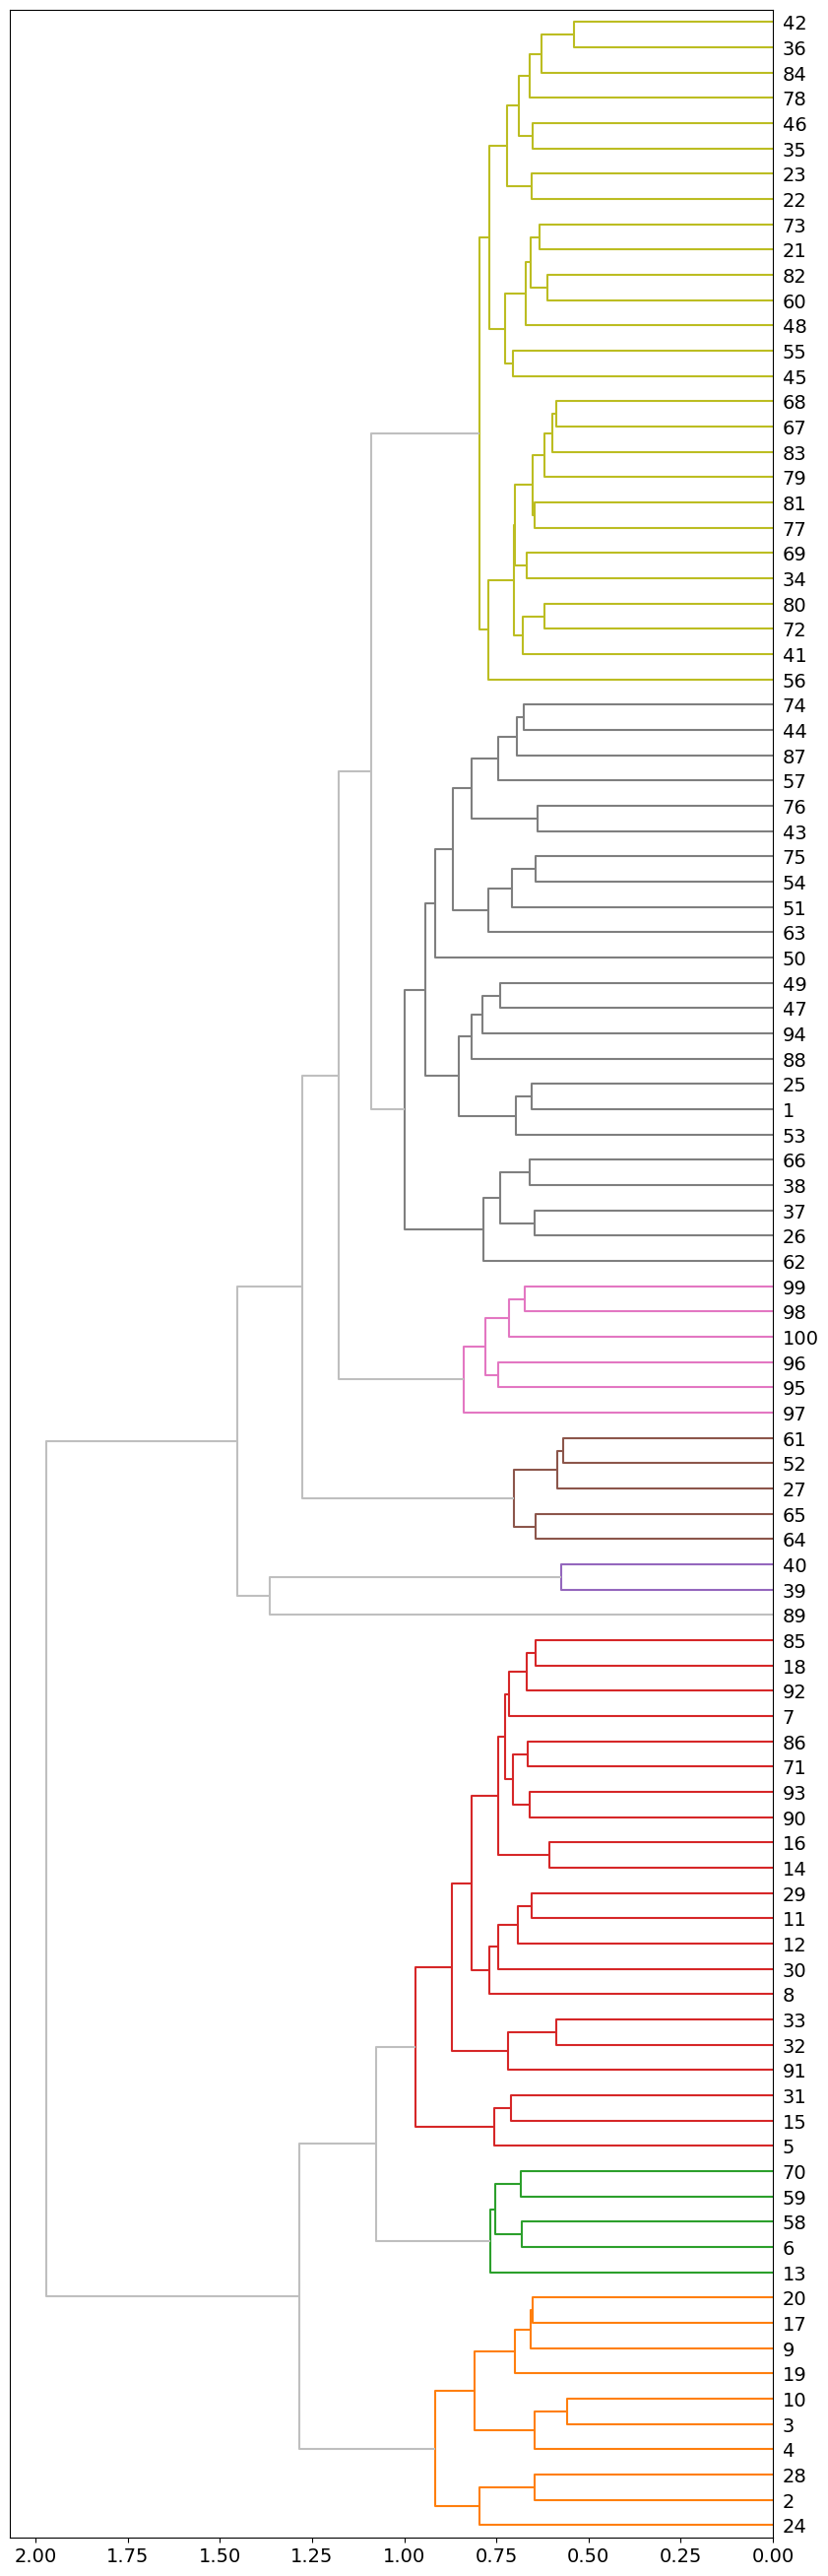

In [ ]:
tfidf_hac.color_thresh = 1 #.75
tfidf_hac.plot_tree()

/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



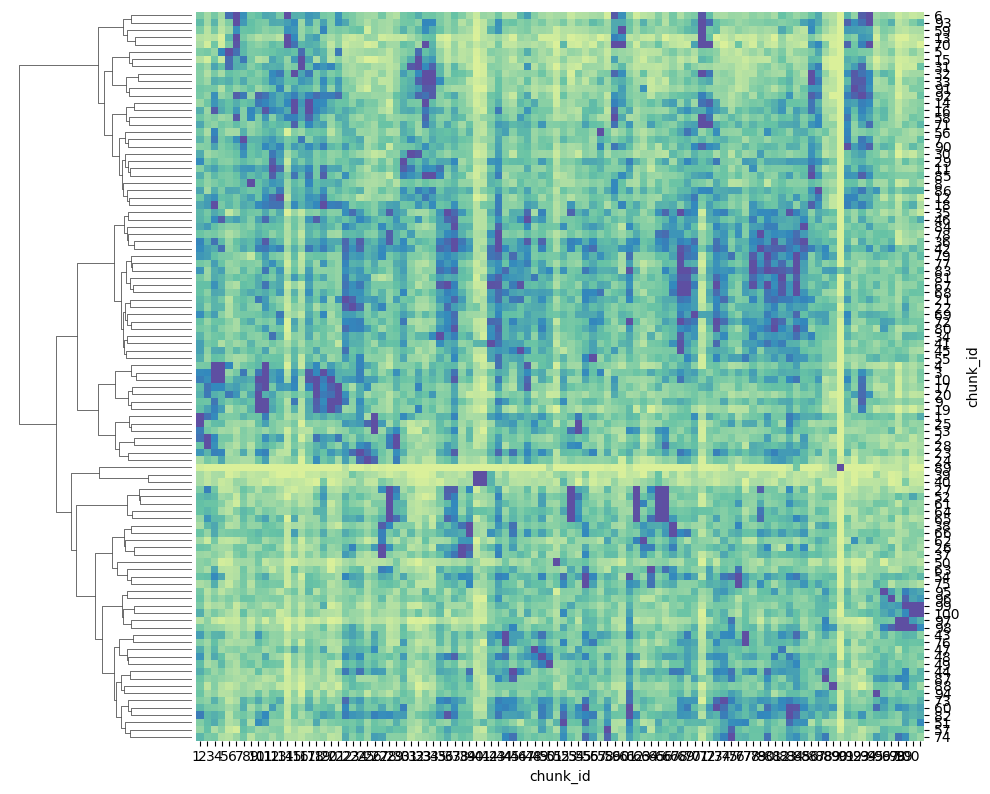

In [ ]:
fig = sns.clustermap(TFIDF_SIM,
               method='ward', metric='euclidean',
               cmap='Spectral', center=0, cbar_pos=None, 
               col_cluster=False, robust=True, 
               xticklabels=True, yticklabels=True)
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
fig.ax_col_dendrogram.set_visible(False)

In [ ]:
tfidf_hac.get_cluster_labels()

In [ ]:
CHUNK['cluster_label'] = tfidf_hac.CLUSTER_LABELS

In [ ]:
try:
    TOKEN = TOKEN.join(CHUNK.cluster_label, on="chunk_id")
except:
    pass

In [ ]:
TOKEN

token_str term_str  chunk_id  cluster_label
chap_num verse_num token_num                                            
1        1         0                In       in         1              7
                   1               the      the         1              7
                   2              name     name         1              7
                   3                of       of         1              7
                   4              God,      god         1              7
...                                ...      ...       ...            ...
114      6         1             among    among       100              5
                   2              jinn     jinn       100              5
                   3               and      and       100              5
                   4             among    among       100              5
                   5          people.”   people       100              5

[140044 rows x 4 columns]

In [ ]:
# CHUNK.style.background_gradient()

In [ ]:
CLUSTER_CHUNK = TOKEN.groupby(['cluster_label','chunk_id']).chunk_id.count().unstack(fill_value=0).astype(bool).astype(int)

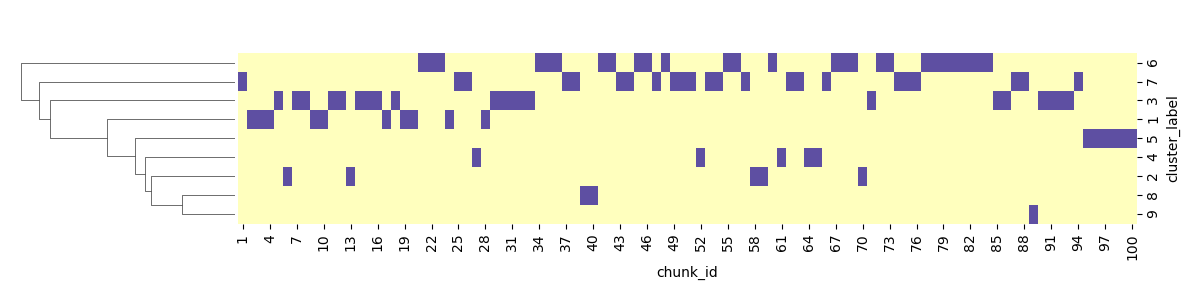

In [ ]:
sns.clustermap(CLUSTER_CHUNK, 
                    cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(12,3))

In [ ]:
CLUSTER = CHUNK.cluster_label.value_counts().to_frame('n_chunks')

In [ ]:
CLUSTER

,n_chunks
cluster_label,
6,27
7,23
3,21
1,10
5,6
2,5
4,5
8,2
9,1


In [ ]:
labels = {}
ord = 0
for lbl in CHUNK.sort_index().cluster_label.values:
    if lbl not in labels:
        ord += 1
        labels[lbl] = ord

In [ ]:
CLUSTER['ord'] = pd.Series(labels)

In [ ]:
CLUSTER.sort_values('ord')

,n_chunks,ord
cluster_label,,
7,23,1
1,10,2
3,21,3
2,5,4
6,27,5
4,5,6
8,2,7
9,1,8
5,6,9


In [ ]:
label_col = "cluster_label"
CLUSTER_TFIDF = (
    TFIDF
    .join(CHUNK[label_col])
    .groupby(label_col)
    .mean()
)

In [ ]:
CLUSTER_TFIDF.T.sample(5).sort_index().T.style.background_gradient(axis=None)

,almighty,informs,reckoning,sight,sorrowing
cluster_label,,,,,
1,0.006624,0.000000,0.007916,0.003877,0.000000
2,0.000000,0.000000,0.027592,0.014074,0.000000
3,0.010986,0.003273,0.001691,0.006806,0.002853
4,0.021023,0.000000,0.008199,0.000000,0.000000
5,0.005469,0.000000,0.019477,0.000000,0.000000
6,0.016044,0.002479,0.004842,0.013663,0.002479
7,0.014689,0.000000,0.007383,0.008472,0.000000
8,0.000000,0.000000,0.000000,0.028794,0.000000
9,0.013188,0.000000,0.000000,0.000000,0.000000


In [ ]:
VOCAB['max_cluster'] = CLUSTER_TFIDF.idxmax()

In [ ]:
CLUSTER['gloss'] = CLUSTER_TFIDF.idxmax(1)
CLUSTER['top_terms'] = CLUSTER_TFIDF.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)

In [ ]:
CLUSTER

,n_chunks,ord,gloss,top_terms
cluster_label,,,,
6,27,5,heavens,"heavens, gods, truth, signs, good, sent, used"
7,23,1,worship,"worship, created, adam, away, lot, know, bring"
3,21,3,messenger,"messenger, fight, believers, hearts, gods, wom..."
1,10,2,revealed,"revealed, scripture, mary, follow, come, moses..."
5,6,9,gracious,"gracious, merciful, man, woe, night, created, ..."
2,5,4,women,"women, men, marry, wives, gods, homes, messenger"
4,5,6,moses,"moses, pharaoh, magicians, magic, throw, staff..."
8,2,7,joseph,"joseph, father, brother, shirt, seduce, seven,..."
9,1,8,marvels,"marvels, deny, lords, jinn, reclining, fruits,..."


In [ ]:
CHUNK['max_cluster'] = (
    TOKEN
    .join(CLUSTER_TFIDF.T, on='term_str')
    .dropna()
    .groupby('chunk_id')[CLUSTER.index]
    .mean()
    .idxmax(1)
)
CHUNK['max_cluster_gloss'] = CHUNK.max_cluster.map(CLUSTER.gloss)

In [ ]:
CHUNK

,n_tokens,cluster_label,max_cluster,max_cluster_gloss
chunk_id,,,,
1,1401,7,7,worship
2,1401,1,1,revealed
3,1401,1,1,revealed
4,1401,1,1,revealed
5,1401,3,3,messenger
...,...,...,...,...
96,1400,5,5,gracious
97,1400,5,5,gracious
98,1400,5,5,gracious


# PCA

In [ ]:
n_comps = 5
pca_engine = PCA(n_components=5)
PCAX = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)
PCAX.index.name = 'chunk_id'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = TFIDF.columns)
LOADINGS.index.name = 'term_str'

In [ ]:
X0 = CHUNK.join(PCAX)

def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.max_cluster_gloss,
        # symbol=X0.max_topic,
        size = [1 for i in range(len(X0))],
        marginal_x='box', 
        marginal_y='box').show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index
    
    px.scatter(LOADINGS.loc[C].join(VOCAB), x, y, 
        title=f"Quantile {quantile} Loadings for {x} and {y}",
        opacity=.5,
        text=C, 
        size='n',
        height=850, width=950).show()
    

In [ ]:
plot_pca(0,1)

In [ ]:
plot_pca(2,3)

**Component Histograms**

In [ ]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='max_cluster_gloss',
           color='max_cluster_gloss', 
           # height=400, width=600, 
           title=f'PC {i}').show()

In [ ]:
for i in range(n_comps):
    comp_box(i)

# NMF

In [ ]:
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

9

In [ ]:
k_cols = [i for i in range(k)]
k_cols

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [ ]:
n_topic_terms = 10
nmf_engine = NMF(n_components=k * 2, max_iter=10000, 
                 init='nndsvdar', # None, 'random', 'nndsvd', 'nndsvda', 'nndsvdar'
                 # alpha_W=.01,
                 # alpha_H=10,
                 solver='mu', 
                 beta_loss='kullback-leibler'
                )

THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)

PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
PHIX = PHI * np.log2(k/PHI.astype(bool).astype(int).sum())
# PHIX = PHI

TOPIC = PHIX.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
TOPIC['gloss'] = PHIX.idxmax(1)
# TOPIC['gloss2'] = PHIX.idxmax(1)
# TOPIC['english'] = TOPIC.gloss.map(VOCAB.gloss)
# TOPIC['english2'] = TOPIC.gloss2.map(VOCAB.gloss)

In [ ]:
THETA_SEQ = THETA_SIM.unstack().to_frame('w')
THETA_SEQ.index.names = ['tmp', 'chunk_id']
THETA_SEQ = THETA_SEQ.query("chunk_id == tmp + 1")
THETA_SEQ = THETA_SEQ.reset_index().drop(columns=['tmp']).set_index('chunk_id')
THETA_SEQ['d'] = 1 - THETA_SEQ.w

In [ ]:
TOPIC

,top_terms,gloss
topic_id,,
0,"defender, direction, benevolent, chiefs, stray...",defender
1,"limits, exemption, allegiance, desertarabs, ma...",limits
2,"magicians, persecute, justification, absence, ...",magicians
3,"vigilant, magicians, deviators, ta, supplied, ...",vigilant
4,"disobedient, pilgrim, sanctity, wild, crib, bi...",disobedient
5,"joseph, shirt, torn, caravan, elevate, whip, g...",joseph
6,"transgression, thunder, withholds, profit, sev...",transgression
7,"strange, penitent, hud, lordso, anxious, flour...",strange
8,"partisans, total, dishearten, perpetrate, room...",partisans


In [ ]:
CHUNK[f'top_topic_{k}'] = THETA.idxmax(1).values

In [ ]:
CHUNK

,n_tokens,cluster_label,max_cluster,max_cluster_gloss,top_topic_9
chunk_id,,,,,
1,1401,7,7,worship,6
2,1401,1,1,revealed,11
3,1401,1,1,revealed,2
4,1401,1,1,revealed,4
5,1401,3,3,messenger,9
...,...,...,...,...,...
96,1400,5,5,gracious,13
97,1400,5,5,gracious,12
98,1400,5,5,gracious,4


In [ ]:
CHUNK['max_topic'] = THETA.idxmax(1)

In [ ]:
CHUNK[['max_cluster_gloss', 'max_topic']].value_counts().unstack(fill_value=0).style.background_gradient()

max_topic,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
max_cluster_gloss,,,,,,,,,,,,,,,,,,
gracious,0,0,0,1,1,0,0,0,0,0,0,0,1,2,0,1,0,1
heavens,2,0,0,0,0,2,2,1,4,1,1,1,3,1,4,3,2,1
joseph,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0
marvels,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
messenger,0,5,1,0,0,1,2,1,1,1,1,3,0,0,0,2,1,2
moses,0,0,3,3,0,0,0,0,0,0,1,0,0,0,0,0,0,0
revealed,0,0,2,0,5,0,0,0,0,0,0,1,0,1,0,0,1,0
women,0,3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
worship,0,0,0,1,1,0,1,3,0,4,1,1,2,2,1,0,0,2


In [ ]:
# THETA.join(CHUNK[['max_topic']]).style.background_gradient(cmap="YlGnBu", axis=0)

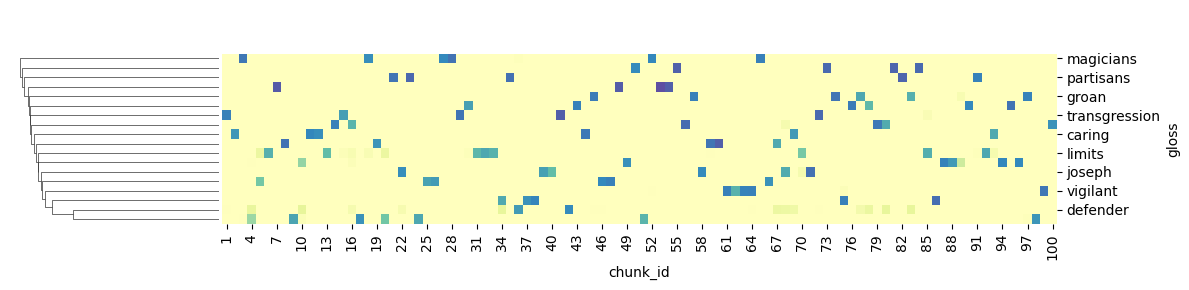

In [ ]:
THETA.columns = TOPIC.gloss
fig = sns.clustermap(THETA.T, 
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(12,3))

# Classify

**Model by THETA**

In [ ]:
CHAP_TOPIC_THETA = (
    TOKEN
    .join(THETA, on='chunk_id')[THETA.columns]
    .groupby(['chap_num'])
    .mean()
)

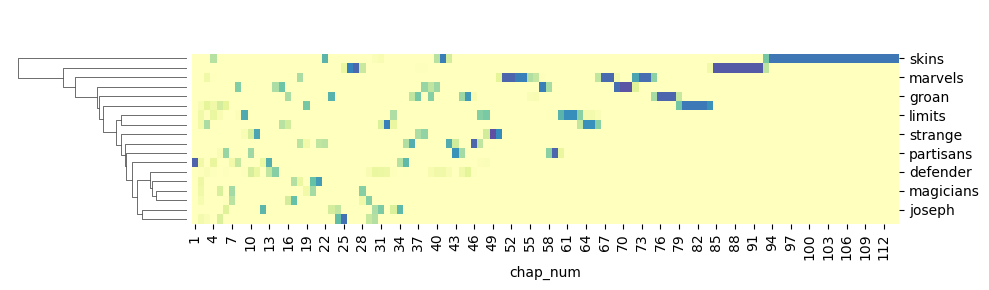

In [ ]:
sns.clustermap(CHAP_TOPIC_THETA.T,
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(10,3));

**Model by PHI**

In [ ]:
CHAP_TOPIC = (
    TOKEN
    .join(PHI.T, on='term_str')
    .dropna()
    .fillna(0)
    .groupby(['chap_num'])[k_cols]
    .mean()
)

# Normalize
# CHAP_TOPIC = (CHAP_TOPIC.T/CHAP_TOPIC.T.sum()).T

In [ ]:
# sns.clustermap(CHAP_TOPIC.T.corr(), cmap='YlGnBu', col_cluster=False);

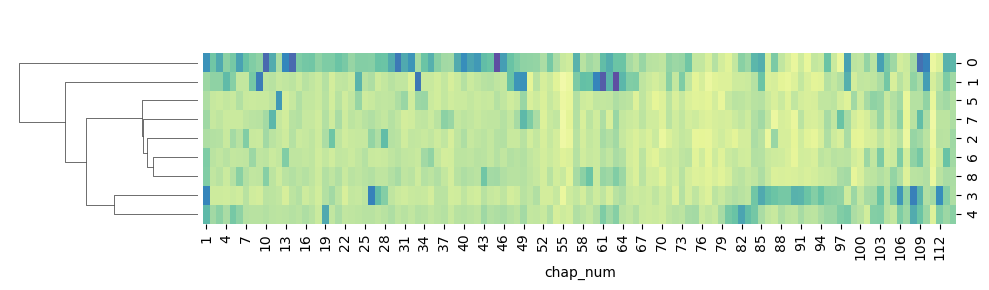

In [ ]:
sns.clustermap(CHAP_TOPIC.T,
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(10,3));

In [ ]:
CHAP['max_topic'] = CHAP_TOPIC[k_cols].idxmax(1)
CHAP['max_topic_theta'] = CHAP_TOPIC_THETA.idxmax(1)
CHAP['max_topic_gloss'] = CHAP.max_topic.map(TOPIC.gloss)

In [ ]:
CHAP

,chap_str,n_tokens,max_topic,max_topic_theta,max_topic_gloss
chap_num,,,,,
1,"Praise be to God, Lord of the Worlds. The Mos...",68,3,transgression,vigilant
2,"Alif, Lam, Meem. This is the Book in which th...",10764,0,immortality,defender
3,"Alif, Lam, Meem. God, there is no god but He,...",6151,0,caring,defender
4,"O people! Fear your Lord, who created you fro...",6343,1,skins,limits
5,O you who believe! Fulfill your commitments. ...,4975,0,disobedient,defender
...,...,...,...,...,...
110,"When there comes God’s victory, and conquest....",43,0,skins,defender
111,"Condemned are the hands of Abee Lahab, and he...",51,3,skins,vigilant
112,"Say, “He is God, the One. God, the Absolute. ...",32,3,skins,vigilant


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Compute color range for centered colormap
z = THETA.T.values
zmin, zmax = z.min(), z.max()
midpoint = 0
vmax = max(abs(zmin - midpoint), abs(zmax - midpoint))
zmin, zmax = midpoint - vmax, midpoint + vmax

# Create subplot layout
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.6, 0.4],
    vertical_spacing=0.1,
    subplot_titles=("Gloss × Chunk Heatmap", "Chunk Distance from Previous")
)

# Heatmap
heatmap = go.Heatmap(
    z=z,
    x=THETA.T.columns,
    y=THETA.T.index,
    colorscale='Spectral',
    zmin=zmin,
    zmax=zmax,
    showscale=False
)
fig.add_trace(heatmap, row=1, col=1)

# Barplot of distances (by similarity)
bar = go.Bar(
    x=THETA_SEQ.index,  # assuming chunk_id is the index
    y=THETA_SEQ['d'],
    marker_color='royalblue'
)
fig.add_trace(bar, row=2, col=1)

# Layout adjustments
fig.update_layout(
    height=600,
    width=1000,
    margin=dict(t=60),
    showlegend=False
)

fig.update_annotations(font_size=14)
fig.update_yaxes(title_text="gloss", row=1, col=1)
fig.update_yaxes(title_text="d", row=2, col=1)
fig.update_xaxes(title_text="chunk_id", row=2, col=1)

fig.show()

In [ ]:
# CHAP[['max_cluster', 'max_topic_theta']].value_counts().unstack(fill_value=0).style.background_gradient()

In [ ]:
# CHAP_TOPIC_THETA

In [ ]:
CHAP_TOPIC_THETA_SIM = pd.DataFrame(cosine_similarity(CHAP_TOPIC_THETA), index=CHAP_TOPIC_THETA.index, columns=CHAP_TOPIC_THETA.index).stack().to_frame('w')
CHAP_TOPIC_THETA_SIM.index.names = ['tmp', 'chap_num']
CHAP_TOPIC_THETA_SIM = CHAP_TOPIC_THETA_SIM.query("chap_num == tmp + 1").reset_index().set_index('chap_num').drop(columns=['tmp'])
CHAP_TOPIC_THETA_SIM['d'] = 1 - CHAP_TOPIC_THETA_SIM.w
# CHAP_TOPIC_THETA_SIM

In [ ]:
CHAP['wdiff'] = CHAP_TOPIC_THETA_SIM.d
CHAP['new'] = (CHAP_TOPIC_THETA_SIM.d > .25).astype(bool)
CHAP.loc[1, 'new'] = True

In [ ]:
# Compute color range for centered colormap

# Create subplot layout
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.6, 0.4],
    vertical_spacing=0.1,
    subplot_titles=("Glosses over Chpaters", "Chapter Distance from Previous")
)

# Heatmap
z = CHAP_TOPIC_THETA.T.values
zmin, zmax = z.min(), z.max()
midpoint = 0
vmax = max(abs(zmin - midpoint), abs(zmax - midpoint))
zmin, zmax = midpoint - vmax, midpoint + vmax
heatmap = go.Heatmap(
    z=z,
    x=CHAP_TOPIC.T.columns,
    y=TOPIC.gloss, #CHAP_TOPIC.T.index,
    colorscale='Spectral',
    zmin=zmin,
    zmax=zmax,
    showscale=False
)
fig.add_trace(heatmap, row=1, col=1)

# Barplot
X = CHAP_TOPIC_THETA_SIM.join(CHAP).reset_index()
bar = go.Bar(
    x = X.chap_num, 
    y = X.d, #.rolling(2).mean(), 
    marker_color='royalblue'
)
fig.add_trace(bar, row=2, col=1)

# Layout adjustments
fig.update_layout(
    height=600,
    width=1000,
    margin=dict(t=60),
    showlegend=False
)

fig.update_annotations(font_size=16)

# fig.update_yaxes(title_text="chapter", row=1, col=1)
fig.update_yaxes(title_text="topic", row=1, col=1)
fig.update_yaxes(title_text="d", row=2, col=1)

fig.update_xaxes(title_text="chapter number", row=2, col=1)

fig.show()

In [ ]:
CHAP

,chap_str,n_tokens,max_topic,max_topic_theta,max_topic_gloss,wdiff,new
chap_num,,,,,,,
1,"Praise be to God, Lord of the Worlds. The Mos...",68,3,transgression,vigilant,NaN,True
2,"Alif, Lam, Meem. This is the Book in which th...",10764,0,immortality,defender,0.627005,True
3,"Alif, Lam, Meem. God, there is no god but He,...",6151,0,caring,defender,0.543859,True
4,"O people! Fear your Lord, who created you fro...",6343,1,skins,limits,0.866363,True
5,O you who believe! Fulfill your commitments. ...,4975,0,disobedient,defender,0.785032,True
...,...,...,...,...,...,...,...
110,"When there comes God’s victory, and conquest....",43,0,skins,defender,0.000000,False
111,"Condemned are the hands of Abee Lahab, and he...",51,3,skins,vigilant,0.000000,False
112,"Say, “He is God, the One. God, the Absolute. ...",32,3,skins,vigilant,0.000000,False


# PART

In [ ]:
PART = CHAP.loc[CHAP.new == True].reset_index()
PART.index.name = 'part_num'
PART = PART.reset_index()
PART.part_num = PART.part_num + 1
PART = PART.set_index('part_num')
PART = PART.sort_index()

In [ ]:
PART

,chap_num,chap_str,n_tokens,max_topic,max_topic_theta,max_topic_gloss,wdiff,new
part_num,,,,,,,,
1,1,"Praise be to God, Lord of the Worlds. The Mos...",68,3,transgression,vigilant,NaN,True
2,2,"Alif, Lam, Meem. This is the Book in which th...",10764,0,immortality,defender,0.627005,True
3,3,"Alif, Lam, Meem. God, there is no god but He,...",6151,0,caring,defender,0.543859,True
4,4,"O people! Fear your Lord, who created you fro...",6343,1,skins,limits,0.866363,True
5,5,O you who believe! Fulfill your commitments. ...,4975,0,disobedient,defender,0.785032,True
6,6,"Praise be to God, Who created the heavens and...",5479,0,partisans,defender,0.678214,True
7,7,"Alif, Lam, Meem, Saad. A Scripture was reveal...",6137,0,magicians,defender,0.974608,True
8,8,"They ask you about the bounties. Say, “The bo...",2167,1,yellowing,limits,0.899292,True
9,9,A declaration of immunity from God and His Mes...,4494,1,limits,limits,0.936737,True


In [ ]:
PART.sample()['chap_str'].values

array([' The Reality. What is the Reality? What will make you understand what the Reality is? Thamood and Aad denied the Catastrophe. As for Thamood, they were annihilated by the Overwhelming. And as for Aad; they were annihilated by a furious, roaring wind. He unleashed it upon them for seven nights and eight days, in succession. You could see the people tossed around, as though they were stumps of hollow palm-trees. Can you see any remnant of them? Then Pharaoh came, and those before him, and the Overturned Cities steeped in sin. But they disobeyed the messenger of their Lord, so He seized them with an overpowering grip. When the waters overflowed, We carried you in the cruising ship. To make it a lesson for you—so that retaining ears may retain it.  Then, when the Trumpet is sounded a single time.  And the earth and the mountains are lifted up, and crushed, with a single crush. On that Day, the Event will come to pass. And the heaven will crack; so on that Day it will be frail. And 